<a href="https://colab.research.google.com/github/iav2002/Assignment_Advanced_Topics_In_DeepLearning/blob/main/part2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2 — Exploratory Data Analysis

This notebook builds the foundation for all Part 2 experiments. We explore the
Warehouse Object Detection Dataset, decide on filtering thresholds based on the
actual data distribution, and produce a clean sample index that every training
notebook will load directly. We already took an investigation locally, I am just repeating the highlights and going deeper to take decisions into how to handle the dataset for the models

1. **Setup** — mount Drive, imports, paths
2. **Why not COCO** — evidence that the COCO/YOLO formats have corrupted labels, while was trickier but ocrrrect
3. **Raw format inspection** — understand the .npy structure and label JSON quirks
4. **Parsing** — build a clean sample index from raw annotations
5. **Class distribution** — histogram, long-tail analysis, class subset decision
6. **Bbox size distribution** — pick a minimum size threshold based on percentiles
7. **Occlusion distribution** — pick an occlusion threshold
8. **Visual sanity check** — confirm bboxes land on the right objects
9. **Final sample index** — save `samples_{split}.json` for the training notebooks

In [1]:
 # mount drive
from google.colab import drive
drive.mount('/content/drive')

# standard library
import json
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Mounted at /content/drive


In [2]:
# all paths in one place
DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/AdvancedDL')

# raw is the source of truth
RAW_ROOT = DRIVE_ROOT / 'raw'
RAW_DIRS = {
    split: {
        'images': RAW_ROOT / split / 'images',
        'anns':   RAW_ROOT / split / 'annotations',
    }
    for split in ['train', 'val', 'test']
}

# coco is kept only for the comparison section (section 2)
COCO_ROOT = DRIVE_ROOT / 'coco'
COCO_ANNS = COCO_ROOT / 'annotations' / 'instances_train.json'
COCO_IMGS = COCO_ROOT / 'images' / 'train'

# output location for the sample index
INDEX_DIR = DRIVE_ROOT / 'sample_index'
INDEX_DIR.mkdir(parents=True, exist_ok=True)

# check everything exists
for split, d in RAW_DIRS.items():
    n_imgs = len(list(d['images'].glob('*.png'))) if d['images'].exists() else 0
    n_anns = len(list(d['anns'].glob('*_bbox.npy'))) if d['anns'].exists() else 0
    print(f'raw/{split}: {n_imgs} images, {n_anns} bbox files')

print(f'\ncoco train annotations exist: {COCO_ANNS.exists()}')
print(f'index output dir: {INDEX_DIR}')

raw/train: 4654 images, 4654 bbox files
raw/val: 1125 images, 1125 bbox files
raw/test: 1124 images, 1124 bbox files

coco train annotations exist: True
index output dir: /content/drive/MyDrive/Colab Notebooks/AdvancedDL/sample_index


## 2. Why not COCO?

The dataset ships in three parallel formats (`raw/`, `coco/`, `yolo/`) that should
contain the same annotations in different encodings. We compare them on a single
image to verify that assumption.

COCO and YOLO are internally consistent but assign bounding boxes to
the wrong class labels. The raw Omniverse output is the only reliable source.
The cells below reproduce the evidence.

In [3]:
# pick one image that exists in the train split
SAMPLE = 'warehouse_000001.png'
STEM = SAMPLE[:-4]

img_path   = RAW_DIRS['train']['images'] / SAMPLE
raw_bbox   = RAW_DIRS['train']['anns'] / f'{STEM}_bbox.npy'
raw_labels = RAW_DIRS['train']['anns'] / f'{STEM}_labels.json'

img = Image.open(img_path)
W, H = img.size
print(f'image: {SAMPLE}, size: {W}x{H}')

# --- RAW annotations ---
arr = np.load(raw_bbox, allow_pickle=True)
with open(raw_labels) as f:
    raw_label_map = json.load(f)

def parse_raw_class(label_str):
    # omniverse tags look like "data,wall" or "ceiling,data" - drop the 'data' meta tag
    parts = [p.strip() for p in label_str.split(',')]
    real = [p for p in parts if p and p != 'data']
    return real[0] if real else None

raw_boxes = []
for entry in arr:
    sid = int(entry['semanticId'])
    info = raw_label_map.get(str(sid))
    if info is None:
        continue
    name = parse_raw_class(info['class'] if isinstance(info, dict) else info)
    if name is None:
        continue
    occl = float(entry['occlusionRatio'])
    # drop degenerate and heavily occluded boxes just for this visualization
    if occl < 0 or occl >= 0.95:
        continue
    x1, y1, x2, y2 = int(entry['x_min']), int(entry['y_min']), int(entry['x_max']), int(entry['y_max'])
    if x1 == 0 and y1 == 0 and x2 >= W - 1 and y2 >= H - 1:
        continue
    if (x2 - x1) < 3 or (y2 - y1) < 3:
        continue
    raw_boxes.append({'box': (x1, y1, x2, y2), 'name': name})

# --- COCO annotations ---
with open(COCO_ANNS) as f:
    coco = json.load(f)
cat_map = {c['id']: c['name'] for c in coco['categories']}
img_id = next(im['id'] for im in coco['images'] if im['file_name'] == SAMPLE)
coco_boxes = []
for ann in coco['annotations']:
    if ann['image_id'] != img_id:
        continue
    x, y, w, h = ann['bbox']
    coco_boxes.append({
        'box': (int(x), int(y), int(x + w), int(y + h)),
        'name': cat_map[ann['category_id']],
    })

print(f'RAW (filtered for visibility): {len(raw_boxes)} boxes')
print(f'COCO: {len(coco_boxes)} boxes')

image: warehouse_000001.png, size: 512x512
RAW (filtered for visibility): 544 boxes
COCO: 18 boxes


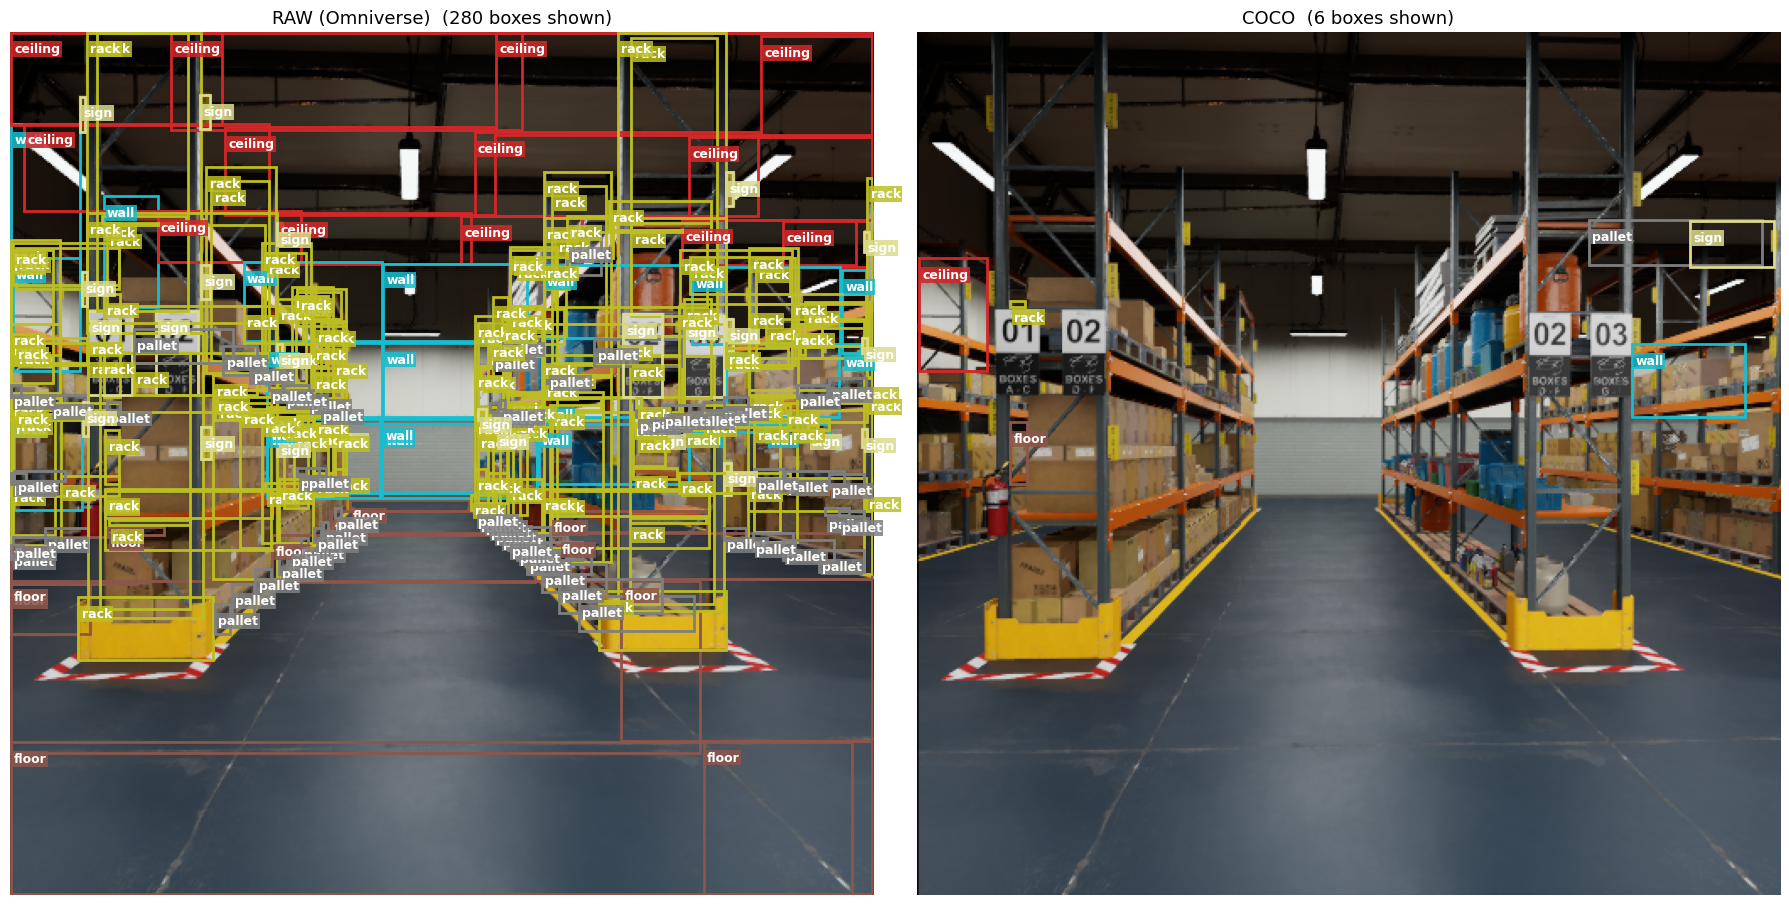

In [4]:
# show only these classes otherwise the raw panel has 600+ boxes and is unreadable
CLASSES_TO_SHOW = ['floor', 'wall', 'pallet', 'sign', 'ceiling', 'rack']

# same color per class across both panels so we can compare
import matplotlib.cm as cm
all_names = sorted(set(r['name'] for r in raw_boxes) | set(r['name'] for r in coco_boxes))
cmap = plt.colormaps['tab20'].resampled(max(len(all_names), 1))
class_colors = {n: cmap(i) for i, n in enumerate(all_names)}

def draw_panel(ax, boxes, title, filter_set):
    ax.imshow(img)
    shown = 0
    for r in boxes:
        if r['name'] not in filter_set:
            continue
        x1, y1, x2, y2 = r['box']
        color = class_colors[r['name']]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1 + 2, max(8, y1 + 12), r['name'], color='white', fontsize=9,
                fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.85, edgecolor='none', pad=1))
        shown += 1
    ax.set_title(f'{title}  ({shown} boxes shown)', fontsize=13)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
draw_panel(axes[0], raw_boxes,  'RAW (Omniverse)', CLASSES_TO_SHOW)
draw_panel(axes[1], coco_boxes, 'COCO',            CLASSES_TO_SHOW)
plt.tight_layout()
plt.show()

## 3. Raw format inspection

Before parsing all 6,903 images, we document the quirks of the raw Omniverse
output. Three things in particular need handling:

1. **Compound class labels**: Omniverse tags primitives with multiple semantic
   tags joined by commas (e.g. `"data,wall"`, `"ceiling,data"`). The `data` tag
   is a meta-tag attached to every primitive and is not a class — the real class
   is whatever else appears in the string.

2. **Typos in the label JSON**: at least one class appears as `barel` (single R)
   instead of `barrel`. We normalize these.

3. **Special bbox values**: a scene-root bbox covering the whole image with
   class `data` is present in every annotation file and must be filtered.
   `occlusionRatio == -1` means uncomputable and should be treated as invalid.

In [5]:
# pick the same image we used in section 2 to keep continuity
sample_npy = RAW_DIRS['train']['anns'] / f'{STEM}_bbox.npy'
sample_lbl = RAW_DIRS['train']['anns'] / f'{STEM}_labels.json'

arr = np.load(sample_npy, allow_pickle=True)
with open(sample_lbl) as f:
    label_map = json.load(f)

print(f'.npy shape: {arr.shape}')
print(f'.npy dtype fields: {arr.dtype.names}')
print(f'\nfirst 3 entries:')
for entry in arr[:3]:
    print(f'  {tuple(entry)}')

print(f'\nlabel json: {len(label_map)} entries')
print(f'first 5 entries:')
for k, v in list(label_map.items())[:5]:
    print(f'  {k}: {v}')

.npy shape: (848,)
.npy dtype fields: ('semanticId', 'x_min', 'y_min', 'x_max', 'y_max', 'occlusionRatio')

first 3 entries:
  (np.uint32(0), np.int32(0), np.int32(0), np.int32(511), np.int32(511), np.float32(-1.0))
  (np.uint32(1), np.int32(424), np.int32(185), np.int32(491), np.int32(228), np.float32(0.92209995))
  (np.uint32(1), np.int32(1), np.int32(134), np.int32(41), np.int32(201), np.float32(0.56839997))

label json: 19 entries
first 5 entries:
  0: {'class': 'data'}
  1: {'class': 'data,wall'}
  2: {'class': 'ceiling,data'}
  3: {'class': 'data,floor'}
  4: {'class': 'data,rack'}


In [6]:
# scan every label file in train to find all unique class strings
# this catches typos and uncommon compound labels we need to handle

all_label_strings = Counter()
n_files = 0

for lbl_file in RAW_DIRS['train']['anns'].glob('*_labels.json'):
    with open(lbl_file) as f:
        label_map = json.load(f)
    for v in label_map.values():
        s = v['class'] if isinstance(v, dict) else v
        all_label_strings[s] += 1
    n_files += 1

print(f'scanned {n_files} files')
print(f'found {len(all_label_strings)} unique class strings\n')
print('top 30 by frequency:')
for s, n in all_label_strings.most_common(30):
    print(f'  {n:7d}  "{s}"')

print('\nbottom 10 (likely typos or rare cases):')
for s, n in all_label_strings.most_common()[-10:]:
    print(f'  {n:7d}  "{s}"')

scanned 4654 files
found 26 unique class strings

top 30 by frequency:
     4654  "data"
     4654  "data,wall"
     4652  "data,floor"
     4445  "data,sign"
     4443  "data,floor_decal"
     4379  "data,pillar"
     4356  "data,rack"
     4329  "box,data"
     4295  "data,pallet"
     3657  "bracket,data"
     3323  "data,lamp"
     2935  "data,wire"
     2911  "ceiling,data"
     2444  "data,fire_extinguisher"
     1597  "data,paper_note"
      957  "crate,data"
      917  "barel,data"
      857  "data,fuse_box"
      829  "barcode,data"
      512  "cone,data"
      499  "bottle,data"
      429  "data,emergency_board"
      373  "bucket,data"
      347  "cart,data"
      273  "data,paper_shortcut"
      256  "data,forklift"

bottom 10 (likely typos or rare cases):
      917  "barel,data"
      857  "data,fuse_box"
      829  "barcode,data"
      512  "cone,data"
      499  "bottle,data"
      429  "data,emergency_board"
      373  "bucket,data"
      347  "cart,data"
      273  "da

In [7]:
# normalize known typos to canonical class names
CLASS_FIXES = {
    'barel': 'barrel', #typo
}

def parse_class(label_str):
    """
    parse an omniverse class string into a single canonical class name.
    drops the 'data' meta tag, keeps the real class, applies typo fixes.
    returns None if no real class is found.
    """
    parts = [p.strip() for p in label_str.split(',')]
    real = [p for p in parts if p and p != 'data']
    if not real:
        return None
    name = real[0]
    return CLASS_FIXES.get(name, name)

# quick test on the strings we found above
test_inputs = ['data,wall', 'ceiling,data', 'data', 'barel', 'pallet,data']
for s in test_inputs:
    print(f'  "{s}" -> {parse_class(s)}')

  "data,wall" -> wall
  "ceiling,data" -> ceiling
  "data" -> None
  "barel" -> barrel
  "pallet,data" -> pallet


## 4. Building the sample index

We walk every annotation file in every split and produce a flat list of samples.
Each sample is one bounding box, ready to become one smaller boxes for training.

At this stage we apply only the **non-negotiable** filters, things that are
broken regardless of any threshold choice:

- entries with no real class (only the `data` meta-tag)
- the scene-root bbox covering the entire image
- bboxes with `occlusionRatio < 0` not computable
- degenerate bboxes (zero or negative area)

Some permanent decissoins like exclusion or imbalances will be done later on.

In [8]:
def build_raw_samples(images_dir, anns_dir):
    """
    walk a split's annotation files and return a flat list of samples.
    only the non-negotiable filters are applied here.
    """
    samples = []
    stats = Counter()  # track why entries are dropped

    for npy_file in sorted(anns_dir.glob('*_bbox.npy')):
        stem = npy_file.stem.replace('_bbox', '')
        lbl_file = anns_dir / f'{stem}_labels.json'
        img_file = images_dir / f'{stem}.png'

        if not lbl_file.exists() or not img_file.exists():
            stats['missing_pair'] += 1
            continue

        arr = np.load(npy_file, allow_pickle=True)
        with open(lbl_file) as f:
            label_map = json.load(f)

        for entry in arr:
            stats['total_entries'] += 1
            sid = int(entry['semanticId'])
            info = label_map.get(str(sid))
            if info is None:
                stats['no_label_entry'] += 1
                continue

            label_str = info['class'] if isinstance(info, dict) else info
            name = parse_class(label_str)
            if name is None:
                stats['no_real_class'] += 1
                continue

            occl = float(entry['occlusionRatio'])
            if occl < 0:
                stats['occl_uncomputable'] += 1
                continue

            x1 = int(entry['x_min'])
            y1 = int(entry['y_min'])
            x2 = int(entry['x_max'])
            y2 = int(entry['y_max'])

            # drop scene-root box (covers entire image)
            # we use 511 because images are 512x512, indexed 0-511
            if x1 == 0 and y1 == 0 and x2 >= 511 and y2 >= 511:
                stats['scene_root'] += 1
                continue

            # drop degenerate boxes
            if (x2 - x1) < 1 or (y2 - y1) < 1:
                stats['degenerate'] += 1
                continue

            samples.append({
                'img_path': str(img_file),
                'bbox': [x1, y1, x2, y2],
                'class_name': name,
                'occlusion': occl,
                'short_side': min(x2 - x1, y2 - y1),
                'area': (x2 - x1) * (y2 - y1),
            })
            stats['kept'] += 1

    return samples, stats

In [9]:
# parse all three splits - this takes a few minutes from drive
# the output is held in memory; we save the filtered final version later

import time

raw_samples = {}
raw_stats = {}

for split in ['train', 'val', 'test']:
    t0 = time.time()
    samples, stats = build_raw_samples(
        RAW_DIRS[split]['images'],
        RAW_DIRS[split]['anns']
    )
    raw_samples[split] = samples
    raw_stats[split] = stats
    elapsed = time.time() - t0
    print(f'{split}: {len(samples):,} samples kept in {elapsed:.1f}s')

print('\nfilter stats per split:')
for split in ['train', 'val', 'test']:
    print(f'\n{split}:')
    s = raw_stats[split]
    total = s['total_entries']
    for key in ['total_entries', 'no_real_class', 'occl_uncomputable',
                'scene_root', 'degenerate', 'kept']:
        n = s.get(key, 0)
        pct = 100 * n / total if total > 0 else 0
        print(f'  {key:22s}: {n:9,d}  ({pct:5.1f}%)')

train: 1,266,019 samples kept in 161.4s
val: 310,024 samples kept in 75.4s
test: 314,767 samples kept in 74.2s

filter stats per split:

train:
  total_entries         : 1,407,372  (100.0%)
  no_real_class         :     4,654  (  0.3%)
  occl_uncomputable     :         0  (  0.0%)
  scene_root            :         1  (  0.0%)
  degenerate            :   136,698  (  9.7%)
  kept                  : 1,266,019  ( 90.0%)

val:
  total_entries         :   344,287  (100.0%)
  no_real_class         :     1,125  (  0.3%)
  occl_uncomputable     :         0  (  0.0%)
  scene_root            :         0  (  0.0%)
  degenerate            :    33,138  (  9.6%)
  kept                  :   310,024  ( 90.0%)

test:
  total_entries         :   349,175  (100.0%)
  no_real_class         :     1,124  (  0.3%)
  occl_uncomputable     :         0  (  0.0%)
  scene_root            :         0  (  0.0%)
  degenerate            :    33,284  (  9.5%)
  kept                  :   314,767  ( 90.1%)


## 5. Class distribution

Before deciding which classes to keep for training, we look at how many
samples each class has after the non-negotiable filters. Heavy long tail
imbalance is expected because is a synhtethic dataset and after manual inspection.

The plot below shows raw counts per class, sorted by frequency.

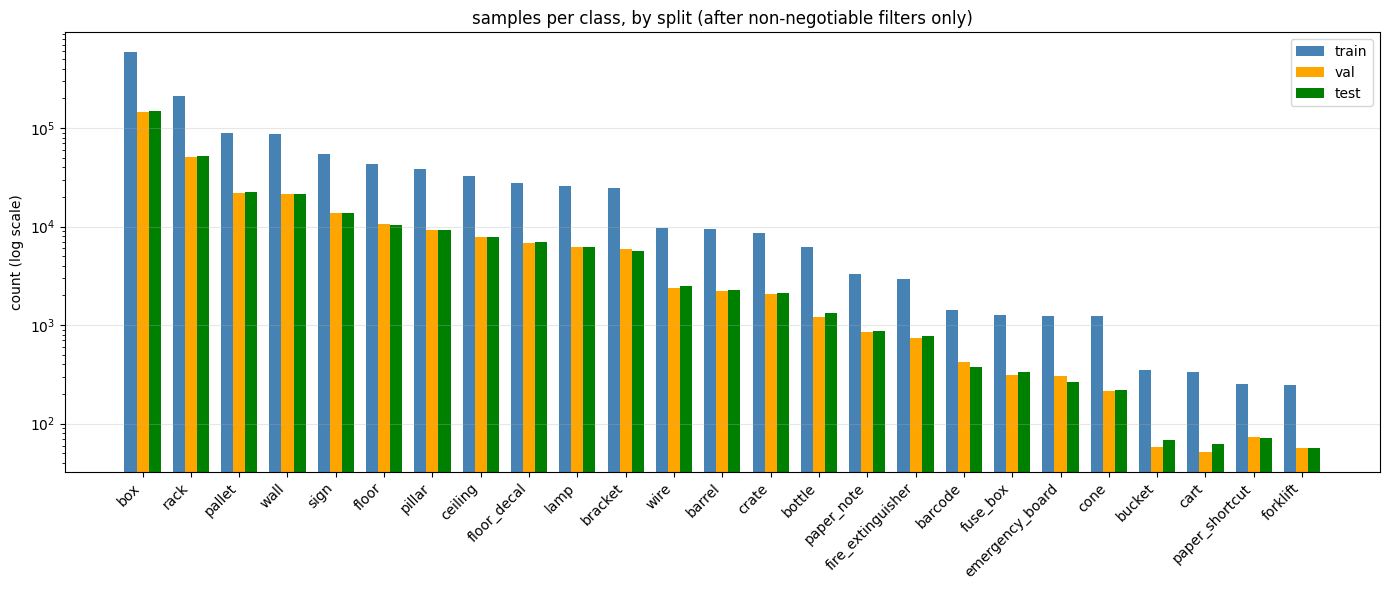

train samples per class:
  box                      586,161  (46.30%)
  rack                     209,269  (16.53%)
  pallet                    88,938  ( 7.03%)
  wall                      87,829  ( 6.94%)
  sign                      54,715  ( 4.32%)
  floor                     43,603  ( 3.44%)
  pillar                    38,252  ( 3.02%)
  ceiling                   32,622  ( 2.58%)
  floor_decal               27,663  ( 2.19%)
  lamp                      25,759  ( 2.03%)
  bracket                   24,637  ( 1.95%)
  wire                       9,586  ( 0.76%)
  barrel                     9,500  ( 0.75%)
  crate                      8,695  ( 0.69%)
  bottle                     6,199  ( 0.49%)
  paper_note                 3,329  ( 0.26%)
  fire_extinguisher          2,933  ( 0.23%)
  barcode                    1,424  ( 0.11%)
  fuse_box                   1,269  ( 0.10%)
  emergency_board            1,226  ( 0.10%)
  cone                       1,223  ( 0.10%)
  bucket                      

In [10]:
# count how many samples each class has in each split
class_counts_train = Counter(s['class_name'] for s in raw_samples['train'])
class_counts_val   = Counter(s['class_name'] for s in raw_samples['val'])
class_counts_test  = Counter(s['class_name'] for s in raw_samples['test'])

# sort by train frequency so the most common class shows up first
sorted_classes = [c for c, _ in class_counts_train.most_common()]

# get the counts in the same order for all three splits so the bars line up
train_vals = [class_counts_train[c] for c in sorted_classes]
val_vals   = [class_counts_val.get(c, 0) for c in sorted_classes]
test_vals  = [class_counts_test.get(c, 0) for c in sorted_classes]

# 3 bars per class (train, val, test) side by side
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(sorted_classes))
ax.bar(x - 0.25, train_vals, width=0.25, label='train', color='steelblue')
ax.bar(x,        val_vals,   width=0.25, label='val',   color='orange')
ax.bar(x + 0.25, test_vals,  width=0.25, label='test',  color='green')
# log scale  the biggest class has 1000x more samples than the smallest
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(sorted_classes, rotation=45, ha='right')
ax.set_ylabel('count (log scale)')
ax.set_title('samples per class, by split (after non-negotiable filters only)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# print the train numbers as a table for reference
print('train samples per class:')
total = sum(train_vals)
for c, n in zip(sorted_classes, train_vals):
    pct = 100 * n / total
    print(f'  {c:22s}  {n:8,d}  ({pct:5.2f}%)')

# imbalance ratio  anything above 100x is severe, above 1000x is extreme
ratio = max(train_vals) / min(train_vals)
print(f'\nimbalance ratio (max/min): {ratio:.1f}x')

## 6. Bounding box size distribution

Each crop will be resized to 224x224 before going through the backbone.
A bbox of 5x5px stretched to 224x224 is mostly noise and "bias", no
real visual information for the model to learn. The threshold question is: what's the minimum
short side (in pixels of the original image) where the resized crop still
carries useful information?

We look at the distribution of short sides to decide.

short_side percentiles (pixels):
  p 1:    1.0
  p 5:    1.0
  p10:    2.0
  p25:    4.0
  p50:   10.0
  p75:   24.0
  p90:   45.0
  p95:   67.0
  p99:  134.0

min: 1, max: 421

% of boxes below candidate thresholds:
  <  10px:  48.7%
  <  16px:  63.9%
  <  20px:  69.5%
  <  24px:  74.1%
  <  32px:  82.9%
  <  40px:  87.5%
  <  48px:  90.8%
  <  64px:  94.3%


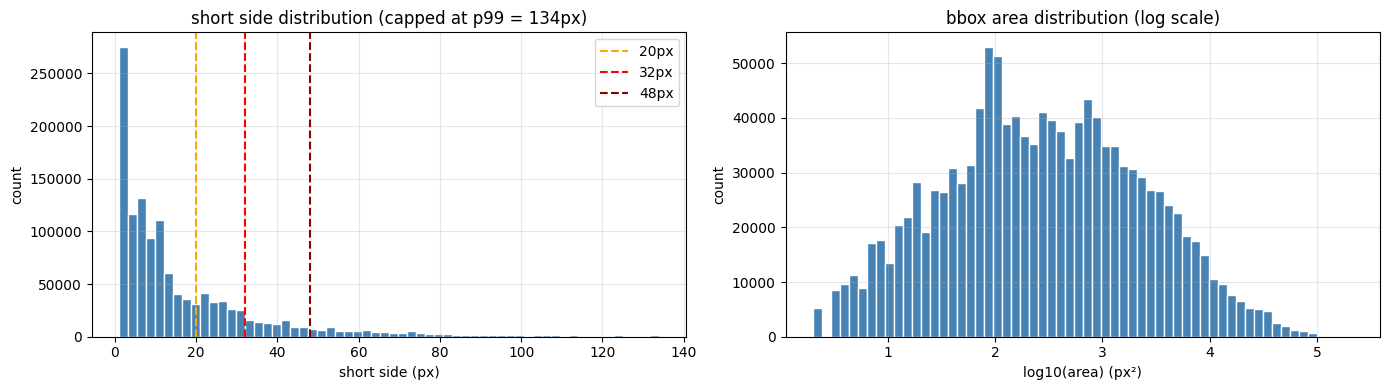

In [11]:
# pull size and area into numpy arrays so we can do percentile math
sides = np.array([s['short_side'] for s in raw_samples['train']])
areas = np.array([s['area'] for s in raw_samples['train']])

# percentiles describe the shape of the distribution
# p50 = median (half the boxes are smaller, half are bigger)
print('short_side percentiles (pixels):')
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f'  p{p:2d}: {np.percentile(sides, p):6.1f}')

print(f'\nmin: {sides.min()}, max: {sides.max()}')

# how many boxes do we lose at each candidate threshold?
# this is what drives the decision in section 8
print('\n% of boxes below candidate thresholds:')
for t in [10, 16, 20, 24, 32, 40, 48, 64]:
    pct = (sides < t).mean() * 100
    print(f'  < {t:3d}px: {pct:5.1f}%')

# two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# cap at p99 so the long tail of huge boxes doesn't squash the interesting part
cap = int(np.percentile(sides, 99))
axes[0].hist(sides[sides <= cap], bins=60, color='steelblue', edgecolor='white')
# vertical lines mark the thresholds we're considering
for t, color in [(20, 'orange'), (32, 'red'), (48, 'darkred')]:
    axes[0].axvline(t, color=color, linestyle='--', linewidth=1.5, label=f'{t}px')
axes[0].set_xlabel('short side (px)')
axes[0].set_ylabel('count')
axes[0].set_title(f'short side distribution (capped at p99 = {cap}px)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# area uses log scale because it spans 5+ orders of magnitude
# (a 5x5 box has area 25, a 400x400 box has area 160000)
axes[1].hist(np.log10(areas + 1), bins=60, color='steelblue', edgecolor='white')
axes[1].set_xlabel('log10(area) (px²)')
axes[1].set_ylabel('count')
axes[1].set_title('bbox area distribution (log scale)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Occlusion distribution

Each bbox carries an `occlusionRatio` from Omniverse: 0 means fully visible,
close to 1 means almost completely hidden. A heavily occluded object's
bbox technically exists but the crop barely contains the object, it's
mostly the occluder.

We look at the distribution to decide a maximum occlusion threshold.

occlusion percentiles:
  p 1: 0.000
  p 5: 0.000
  p10: 0.030
  p25: 0.238
  p50: 0.573
  p75: 0.831
  p90: 0.913
  p95: 0.952
  p99: 0.989

min: 0.000, max: 1.000

% of boxes above candidate occlusion thresholds:
  > 0.50:  54.8%
  > 0.70:  40.4%
  > 0.80:  29.5%
  > 0.90:  11.9%
  > 0.95:   5.2%
  > 0.98:   2.0%


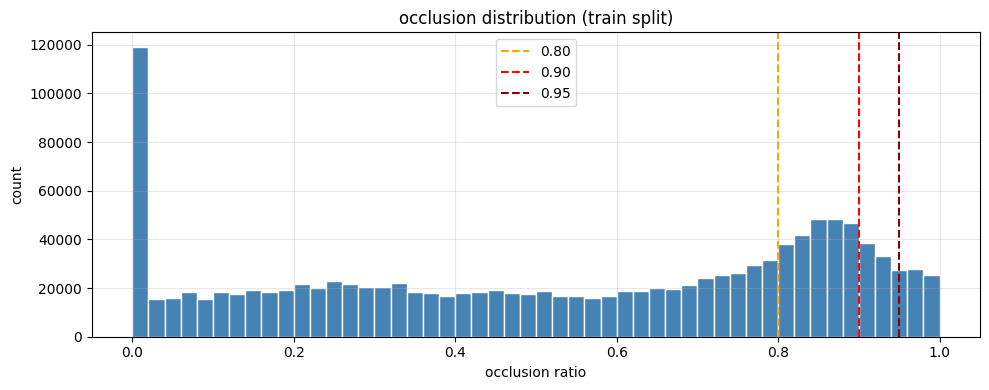

In [12]:
# pull occlusion values into a numpy array
occl = np.array([s['occlusion'] for s in raw_samples['train']])

# percentiles same idea as the size cell
# remember: 0 = fully visible, 1 = fully hidden
print('occlusion percentiles:')
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f'  p{p:2d}: {np.percentile(occl, p):.3f}')

print(f'\nmin: {occl.min():.3f}, max: {occl.max():.3f}')

# at occlusion > 0.80 the object is more than 80% hidden
# the bbox is still in the file but the crop would be mostly the thing in front
print('\n% of boxes above candidate occlusion thresholds:')
for t in [0.50, 0.70, 0.80, 0.90, 0.95, 0.98]:
    pct = (occl > t).mean() * 100
    print(f'  > {t:.2f}: {pct:5.1f}%')

# histogram with vertical lines at candidate thresholds
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(occl, bins=50, color='steelblue', edgecolor='white')
for t, color in [(0.80, 'orange'), (0.90, 'red'), (0.95, 'darkred')]:
    ax.axvline(t, color=color, linestyle='--', linewidth=1.5, label=f'{t:.2f}')
ax.set_xlabel('occlusion ratio')
ax.set_ylabel('count')
ax.set_title('occlusion distribution (train split)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Choosing thresholds

Sections 5-7 showed three things that need filtering decisions:

- The class distribution is heavily imbalanced (over 2000x ratio between most
  and least frequent class) small classes won't learn as good.
- Bbox sizes span a huge range, with 70% of boxes below 20px short side
  these are mostly unusable after resize to 224x224.
- Occlusion is bimodal: many fully visible objects + many heavily-hidden ones
  whose bbox exists but the crop is mostly the occluder.

The goal of this section is to commit to one config and save the resulting
sample index. We sweep candidate combinations first, then justify the final
choice.

In [13]:
# tries different combinations of (size, occlusion, min-samples) and reports
# how many classes survive and how many train samples remain
def survivors(samples, min_side, max_occl, min_per_class):
    # first apply size + occlusion filters at the sample level
    filtered = [s for s in samples
                if s['short_side'] >= min_side and s['occlusion'] <= max_occl]
    # then count per class and drop classes below the minimum
    counts = Counter(s['class_name'] for s in filtered)
    keep_classes = {c for c, n in counts.items() if n >= min_per_class}
    final = [s for s in filtered if s['class_name'] in keep_classes]
    return final, counts, keep_classes

# candidate combinations to compare
candidates = [
    (32, 0.80, 5000),
    (32, 0.80, 3000),
    (35, 0.80, 5000),
    (35, 0.80, 3000),
    (40, 0.80, 5000),
    (48, 0.80, 5000),
]

print(f'{"min_side":>8} {"max_occl":>8} {"min/cls":>7} | {"classes":>7} {"samples":>10} {"req4":>5}')
print('-' * 60)

required = {'floor', 'wall', 'pallet', 'sign'}

for min_side, max_occl, min_pc in candidates:
    final, counts, keep = survivors(raw_samples['train'], min_side, max_occl, min_pc)
    has_required = len(required & keep) == 4
    req_marker = 'ok' if has_required else 'MISS'
    print(f'{min_side:>8} {max_occl:>8.2f} {min_pc:>7} | '
          f'{len(keep):>7} {len(final):>10,d} {req_marker:>5}')

min_side max_occl min/cls | classes    samples  req4
------------------------------------------------------------
      32     0.80    5000 |       9    192,289  MISS
      32     0.80    3000 |       9    192,289  MISS
      35     0.80    5000 |       9    172,236  MISS
      35     0.80    3000 |       9    172,236  MISS
      40     0.80    5000 |       8    138,867  MISS
      48     0.80    5000 |       6     96,650  MISS


In [14]:
# for each candidate, show which of the 4 required classes survive and with how many samples
required = ['floor', 'wall', 'pallet', 'sign']

for min_side, max_occl, min_pc in candidates:
    filtered = [s for s in raw_samples['train']
                if s['short_side'] >= min_side and s['occlusion'] <= max_occl]
    counts = Counter(s['class_name'] for s in filtered)
    print(f'\nmin_side={min_side}, max_occl={max_occl}, min_per_class={min_pc}:')
    for c in required:
        n = counts.get(c, 0)
        status = 'KEEP' if n >= min_pc else 'DROP'
        print(f'  {c:8s}: {n:6,d} samples  [{status}]')


min_side=32, max_occl=0.8, min_per_class=5000:
  floor   : 16,956 samples  [KEEP]
  wall    : 40,709 samples  [KEEP]
  pallet  :  8,987 samples  [KEEP]
  sign    :    621 samples  [DROP]

min_side=32, max_occl=0.8, min_per_class=3000:
  floor   : 16,956 samples  [KEEP]
  wall    : 40,709 samples  [KEEP]
  pallet  :  8,987 samples  [KEEP]
  sign    :    621 samples  [DROP]

min_side=35, max_occl=0.8, min_per_class=5000:
  floor   : 16,493 samples  [KEEP]
  wall    : 38,406 samples  [KEEP]
  pallet  :  7,958 samples  [KEEP]
  sign    :    518 samples  [DROP]

min_side=35, max_occl=0.8, min_per_class=3000:
  floor   : 16,493 samples  [KEEP]
  wall    : 38,406 samples  [KEEP]
  pallet  :  7,958 samples  [KEEP]
  sign    :    518 samples  [DROP]

min_side=40, max_occl=0.8, min_per_class=5000:
  floor   : 15,120 samples  [KEEP]
  wall    : 33,919 samples  [KEEP]
  pallet  :  6,439 samples  [KEEP]
  sign    :    354 samples  [DROP]

min_side=48, max_occl=0.8, min_per_class=5000:
  floor   : 

In [15]:
# how does each filter individually affect sign?
sign_all = [s for s in raw_samples['train'] if s['class_name'] == 'sign']
print(f'sign total: {len(sign_all):,}')

# only size filter
sizes_to_test = [0, 16, 20, 24, 28, 32, 40]
print('\nsign survival by min_side (no occlusion filter):')
for t in sizes_to_test:
    n = sum(1 for s in sign_all if s['short_side'] >= t)
    print(f'  >= {t:2d}px: {n:6,d} samples ({100*n/len(sign_all):.1f}%)')

# only occlusion filter
print('\nsign survival by max_occlusion (no size filter):')
for t in [1.0, 0.95, 0.90, 0.80, 0.70, 0.50]:
    n = sum(1 for s in sign_all if s['occlusion'] <= t)
    print(f'  <= {t:.2f}: {n:6,d} samples ({100*n/len(sign_all):.1f}%)')

sign total: 54,715

sign survival by min_side (no occlusion filter):
  >=  0px: 54,715 samples (100.0%)
  >= 16px:  1,581 samples (2.9%)
  >= 20px:  1,248 samples (2.3%)
  >= 24px:    987 samples (1.8%)
  >= 28px:    825 samples (1.5%)
  >= 32px:    644 samples (1.2%)
  >= 40px:    367 samples (0.7%)

sign survival by max_occlusion (no size filter):
  <= 1.00: 54,715 samples (100.0%)
  <= 0.95: 54,283 samples (99.2%)
  <= 0.90: 53,291 samples (97.4%)
  <= 0.80: 51,157 samples (93.5%)
  <= 0.70: 48,211 samples (88.1%)
  <= 0.50: 46,595 samples (85.2%)


In [16]:
# for every class, show the short_side percentile profile
# tells us which classes are "tiny by nature" vs "compact objects"
classes_in_data = sorted(set(s['class_name'] for s in raw_samples['train']))

print(f'{"class":22s} {"count":>8s}  {"p50":>5s} {"p75":>5s} {"p90":>5s} {"p95":>5s}')
print('-' * 55)
for c in classes_in_data:
    sides_c = np.array([s['short_side'] for s in raw_samples['train'] if s['class_name'] == c])
    if len(sides_c) < 100:
        continue
    p50 = np.percentile(sides_c, 50)
    p75 = np.percentile(sides_c, 75)
    p90 = np.percentile(sides_c, 90)
    p95 = np.percentile(sides_c, 95)
    print(f'{c:22s} {len(sides_c):>8,d}  {p50:>5.0f} {p75:>5.0f} {p90:>5.0f} {p95:>5.0f}')

class                     count    p50   p75   p90   p95
-------------------------------------------------------
barcode                   1,424      2     3     3     7
barrel                    9,500      5     9    16    24
bottle                    6,199      2     5     7     9
box                     586,161      8    14    27    33
bracket                  24,637      4    11    13    19
bucket                      352      9    29    46    53
cart                        335     22    26    53    57
ceiling                  32,622     27    45    68    74
cone                      1,223     11    22    36    37
crate                     8,695      4     7    14    18
emergency_board           1,226      8    12    25    28
fire_extinguisher         2,933      8    10    16    28
floor                    43,603     19    59   127   151
floor_decal              27,663     10    29    67    86
forklift                    245     19    64    99   184
fuse_box                  1,269 

In [17]:
# two-tier filter based on object physical category
LABEL_LIKE = {'barcode', 'bottle', 'paper_note', 'paper_shortcut', 'sign'}

def tier_thresh(class_name):
    return 400 if class_name in LABEL_LIKE else 1024

# apply tiered area filter + occlusion filter
MIN_PER_CLASS = 3000
MAX_OCCLUSION = 0.80

filtered = [s for s in raw_samples['train']
            if s['area'] >= tier_thresh(s['class_name'])
            and s['occlusion'] <= MAX_OCCLUSION]

counts = Counter(s['class_name'] for s in filtered)
keep_classes = {c for c, n in counts.items() if n >= MIN_PER_CLASS}
final = [s for s in filtered if s['class_name'] in keep_classes]

required = {'floor', 'wall', 'pallet', 'sign'}
print(f'surviving classes: {len(keep_classes)}')
print(f'total train samples: {len(final):,}')
print(f'required 4 all present: {required.issubset(keep_classes)}')
print()
print(f'{"class":22s} {"tier":>5s} {"thresh":>6s} {"count":>8s} {"status":>6s}')
print('-' * 55)
for c in sorted(counts, key=lambda x: -counts[x]):
    tier = 'label' if c in LABEL_LIKE else 'obj'
    thr = tier_thresh(c)
    status = 'KEEP' if c in keep_classes else 'DROP'
    print(f'{c:22s} {tier:>5s} {thr:>6d} {counts[c]:>8,d} {status:>6s}')

surviving classes: 10
total train samples: 317,689
required 4 all present: False

class                   tier thresh    count status
-------------------------------------------------------
rack                     obj   1024  102,673   KEEP
box                      obj   1024   50,055   KEEP
wall                     obj   1024   49,378   KEEP
pillar                   obj   1024   24,702   KEEP
floor                    obj   1024   23,786   KEEP
ceiling                  obj   1024   22,332   KEEP
pallet                   obj   1024   19,441   KEEP
lamp                     obj   1024   11,220   KEEP
floor_decal              obj   1024    9,420   KEEP
wire                     obj   1024    4,682   KEEP
sign                   label    400    2,424   DROP
bracket                  obj   1024    1,518   DROP
barrel                   obj   1024      435   DROP
fire_extinguisher        obj   1024      332   DROP
cone                     obj   1024      250   DROP
crate                    obj  

# 8.1 Final Config:

I decided to adopt a **two-tier filter** based on the physical category of the object (after a back and forth with Claude):

- **Label-like objects** (sign, barcode, paper_note, paper_shortcut, bottle):
  small by design — they are information carriers attached to bigger things.
  Threshold: area ≥ 400 px², short side ≥ 12 px.
- **Physical objects** (everything else):
  threshold: area ≥ 1024 px², short side ≥ 28 px.

Both categories share occlusion ≤ 0.80 and a minimum of 1500 samples per class
for that class to survive into the training set. The 1500 floor was chosen
specifically to preserve `sign` (which has 1759 samples after filtering)
without lowering it further than necessary. Class imbalance among surviving
classes is handled via class weights in the loss, not undersampling —
discarding usable samples weakens feature learning more than mild imbalance
does.

**Decision**: two-tier (area + short_side) filter, occlusion ≤ 0.80,
min_per_class = 1500.

**Alternative rejected (a)**: single global size threshold — rejected because
no single value preserves all four required classes.

**Alternative rejected (b)**: undersampling the majority classes — rejected
because pre-trained backbones benefit from seeing many diverse samples;
class weights achieve the same effect without throwing data away.

---

**Update (added after Experiment 1):** the full 225,770-sample train set was
computationally inviable in Colab (~50min preload, ~5min/epoch, projecting ~3h
per variant). Train is capped at 5000 samples/class via seeded random sampling.
Val and test stay uncapped to preserve evaluation integrity. The cap is
acceptable because the data is synthetic — 60k crops of `rack` are
near-duplicates of one 3D asset under varied lighting, so capping reduces
redundancy without losing meaningful diversity. Imbalance ratio drops from
~35x to ~3x as a side benefit.

**Alternative rejected**: capping val and test as well. Rejected because
noisy evaluation undermines the comparison between PEFT methods.

In [18]:
# final config - all thresholds that filtering depends on, in one place
LABEL_LIKE = {'barcode', 'bottle', 'paper_note', 'paper_shortcut', 'sign'}
THRESH_LABEL = {'area': 400,  'short_side': 12}
THRESH_OBJ   = {'area': 1024, 'short_side': 28}
MAX_OCCLUSION = 0.80
MIN_PER_CLASS = 1500
CAP_PER_CLASS = 5000  # added after Experiment 1, see markdown above
CAP_SEED = 42

# single function that decides if a sample passes all filters
def passes(s):
    t = THRESH_LABEL if s['class_name'] in LABEL_LIKE else THRESH_OBJ
    return (s['area'] >= t['area']
            and s['short_side'] >= t['short_side']
            and s['occlusion'] <= MAX_OCCLUSION)

# step 1 decide which classes survive based on TRAIN counts only
train_filtered = [s for s in raw_samples['train'] if passes(s)]
train_counts = Counter(s['class_name'] for s in train_filtered)
keep_classes = sorted({c for c, n in train_counts.items() if n >= MIN_PER_CLASS})

# safety check: required classes for Part 3 must all be present
required = {'floor', 'wall', 'pallet', 'sign'}
missing = required - set(keep_classes)
assert not missing, f'required classes missing: {missing}'

# step 2 build class -> integer label mapping (alphabetical for reproducibility)
CLASS_TO_IDX = {c: i for i, c in enumerate(keep_classes)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(keep_classes)

# step 3 apply filters to all three splits
def apply_to_split(samples):
    out = []
    for s in samples:
        if s['class_name'] not in CLASS_TO_IDX or not passes(s):
            continue
        out.append({**s, 'label': CLASS_TO_IDX[s['class_name']]})
    return out

final_samples = {split: apply_to_split(raw_samples[split])
                 for split in ['train', 'val', 'test']}

# step 4 cap train at CAP_PER_CLASS samples per class (val/test untouched)
import random as _random
by_class = {}
for s in final_samples['train']:
    by_class.setdefault(s['class_name'], []).append(s)

_random.seed(CAP_SEED)
capped_train = []
for cls in sorted(by_class.keys()):
    items = by_class[cls]
    if len(items) > CAP_PER_CLASS:
        items = _random.sample(items, CAP_PER_CLASS)
    capped_train.extend(items)

_random.shuffle(capped_train)
final_samples['train'] = capped_train

# step 5 checks
print(f'kept {NUM_CLASSES} classes: {keep_classes}\n')
print(f'train: {len(final_samples["train"]):,}, '
      f'val: {len(final_samples["val"]):,}, '
      f'test: {len(final_samples["test"]):,}')
print('\nper-class counts (train, after cap):')
train_final_counts = Counter(s['class_name'] for s in final_samples['train'])
for c in keep_classes:
    n = train_final_counts[c]
    marker = ' <-- required' if c in required else ''
    print(f'  {c:15s} {n:>5,d}{marker}')

# step 6 save sample index JSONs
import json as _json
for split, s in final_samples.items():
    with open(INDEX_DIR / f'samples_{split}.json', 'w') as f:
        _json.dump(s, f)

vocab = {
    'class_to_idx': CLASS_TO_IDX,
    'idx_to_class': {str(k): v for k, v in IDX_TO_CLASS.items()},
    'keep_classes': keep_classes,
    'config': {
        'thresh_label': THRESH_LABEL,
        'thresh_object': THRESH_OBJ,
        'label_like_classes': sorted(LABEL_LIKE),
        'max_occlusion': MAX_OCCLUSION,
        'min_per_class': MIN_PER_CLASS,
        'cap_per_class_train': CAP_PER_CLASS,
        'cap_seed': CAP_SEED,
    },
}
with open(INDEX_DIR / 'class_vocab.json', 'w') as f:
    _json.dump(vocab, f, indent=2)


# CORRECTION AFTER EXPERIMENT 1 - COMMENTED AS A DEAD END
# # step 5: save sample index JSONs
# # these are pointers + metadata, NOT cropped images. cropping happens at
# # training time via PIL.Image.crop() inside the Dataset class
# import json as _json
# for split, s in final_samples.items():
#     out_path = INDEX_DIR / f'samples_{split}.json'
#     with open(out_path, 'w') as f:
#         _json.dump(s, f)
#     print(f'saved {out_path} ({len(s):,} samples)')

# # also save the vocab + config so training notebooks can rebuild the same setup
# vocab = {
#     'class_to_idx': CLASS_TO_IDX,
#     'idx_to_class': {str(k): v for k, v in IDX_TO_CLASS.items()},
#     'keep_classes': keep_classes,
#     'config': {
#         'thresh_label': THRESH_LABEL,
#         'thresh_object': THRESH_OBJ,
#         'label_like_classes': sorted(LABEL_LIKE),
#         'max_occlusion': MAX_OCCLUSION,
#         'min_per_class': MIN_PER_CLASS,
#     },
# }
# with open(INDEX_DIR / 'class_vocab.json', 'w') as f:
#     _json.dump(vocab, f, indent=2)
# print('saved class_vocab.json')

kept 11 classes: ['box', 'ceiling', 'floor', 'floor_decal', 'lamp', 'pallet', 'pillar', 'rack', 'sign', 'wall', 'wire']

train: 50,259, val: 55,426, test: 55,529

per-class counts (train, after cap):
  box             5,000
  ceiling         5,000
  floor           5,000 <-- required
  floor_decal     5,000
  lamp            5,000
  pallet          5,000 <-- required
  pillar          5,000
  rack            5,000
  sign            1,759 <-- required
  wall            5,000 <-- required
  wire            3,500


## 9. Visual sanity check

We sample crops from each surviving class to verify two things:
1. labels
match what's actually visible in the crop, and  
2. crops carry enough visual
detail after resizing to 224x224 to be classifiable. (some wont' do but ResNet50 is "experienced" on this)

The `sign` class gets its own panel because it sits at the boundary of our
size threshold, we want to see what we kept and confirm signs are still
recognizable which we did

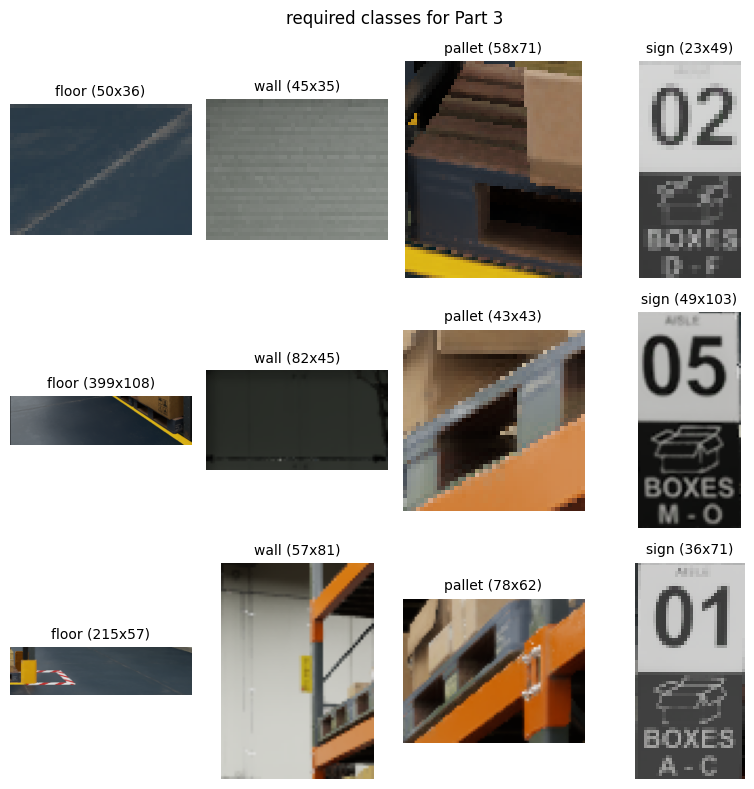

In [19]:
# 4 columns (one per required class) x 4 rows = 4 examples per class
random.seed(42)
fig, axes = plt.subplots(3, 4, figsize=(8, 8))
required_order = ['floor', 'wall', 'pallet', 'sign']

for col, cls in enumerate(required_order):
    cls_samples = [s for s in final_samples['train'] if s['class_name'] == cls]
    chosen = random.sample(cls_samples, 3)
    for row, s in enumerate(chosen):
        img = Image.open(s['img_path']).convert('RGB')
        x1, y1, x2, y2 = s['bbox']
        crop = img.crop((x1, y1, x2, y2))
        axes[row, col].imshow(crop)
        axes[row, col].set_title(f"{cls} ({x2-x1}x{y2-y1})", fontsize=10)
        axes[row, col].axis('off')

plt.suptitle('required classes for Part 3', fontsize=12)
plt.tight_layout()
plt.show()

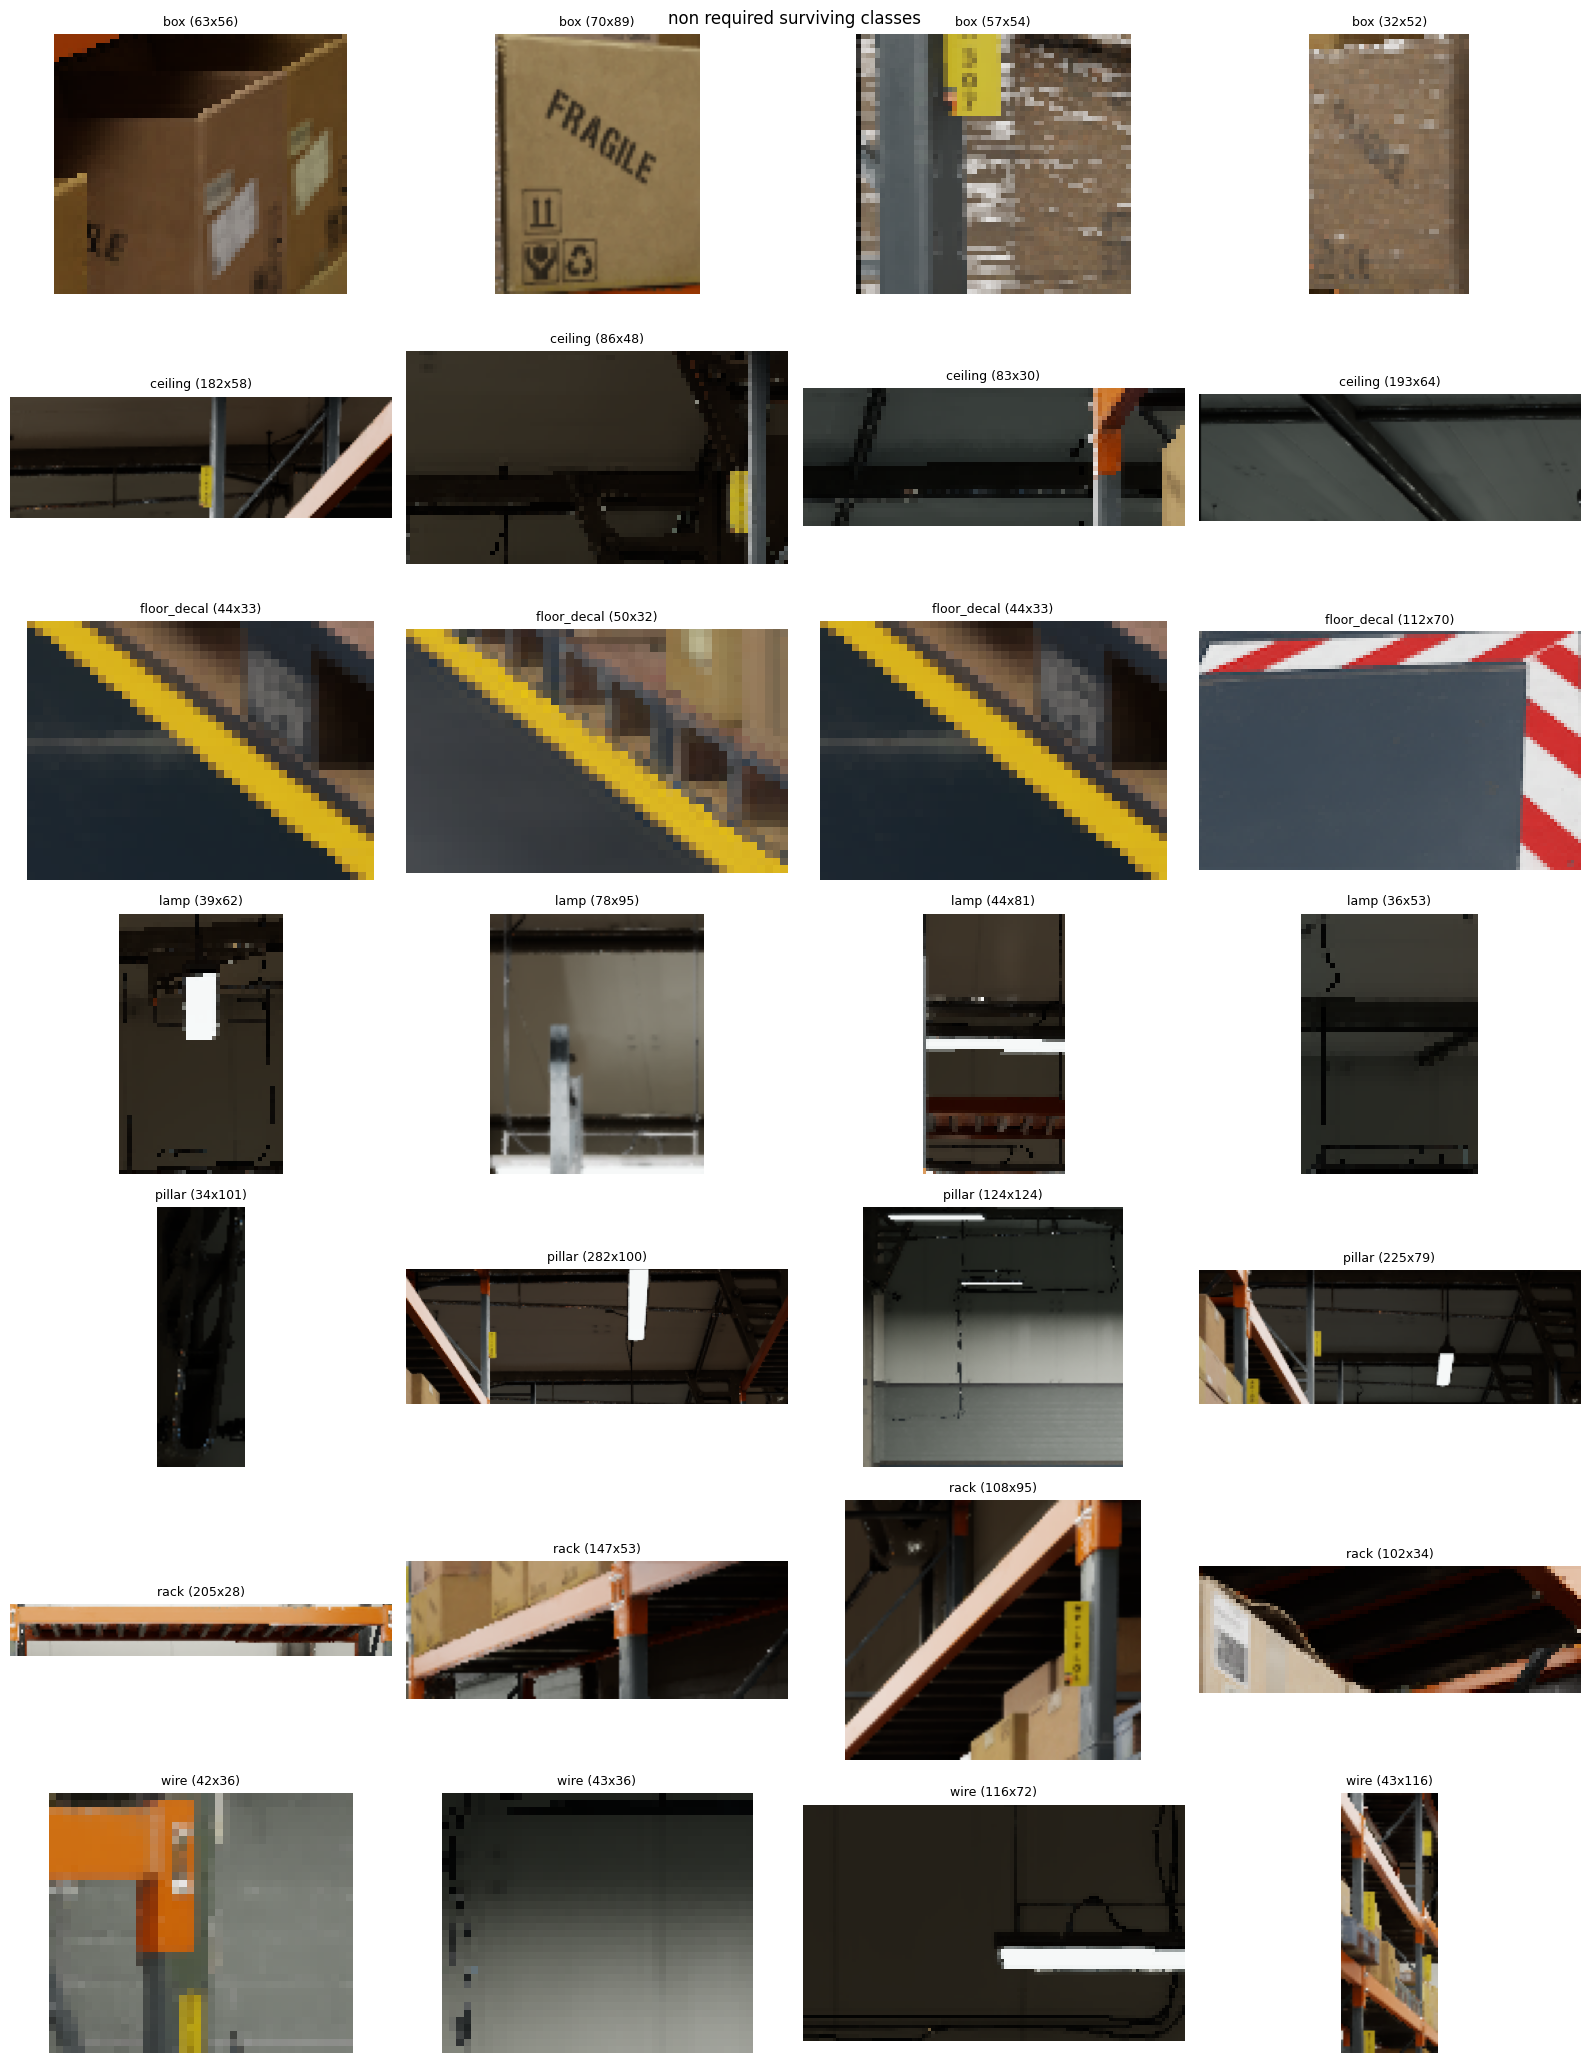

In [20]:
# the other 7 classes
other_classes = [c for c in keep_classes if c not in {'floor', 'wall', 'pallet', 'sign'}]
random.seed(21)
fig, axes = plt.subplots(len(other_classes), 4, figsize=(16, 3 * len(other_classes)))

for row, cls in enumerate(other_classes):
    cls_samples = [s for s in final_samples['train'] if s['class_name'] == cls]
    chosen = random.sample(cls_samples, 4)
    for col, s in enumerate(chosen):
        img = Image.open(s['img_path']).convert('RGB')
        x1, y1, x2, y2 = s['bbox']
        crop = img.crop((x1, y1, x2, y2))
        axes[row, col].imshow(crop)
        axes[row, col].set_title(f"{cls} ({x2-x1}x{y2-y1})", fontsize=9)
        axes[row, col].axis('off')

plt.suptitle('non required surviving classes', fontsize=12)
plt.tight_layout()
plt.show()